### 👀교차 검증(Cross Validation)
- 기존 방식에서는 데이터 세트에서 학습 데이터 세트와 테스트 데이터 세트를 분리한 뒤 모델 검증을 진행한다.
- 교차 검증 시, 학습 데이터를 다시 분할하여 학습 데이터와 모델 성능을 1차 평가하는 검증 데이터로 나눈다.
- 여러번 실제 데이터와 검증해서 정확도라는 수치를 더 신뢰할 수 있게 된다.

<img src="./images/cross_validation01.png" width="500">  

### 교차 검증의 장단점
- 👍특정 데이터 세트에 대한 과적합 방지(특정 데이터 세트에 과적합인지 아닌지를 정확히 진단가능)
- 👍검증 데이터 세트 분리로 인한 과소적합 방지(검증 데이터를 사용했음에도 훈련 데이터 전체 학습)
- 👎모델 훈련, 모델 평가에 소요되는 시간 증가  
⛳ 과적합을 피하고 하이퍼 파라미터를 튜닝함으로써 모델을 일반화하고 신뢰성을 증가시키기 위해서 사용한다.

### 교차 검증의 종류
##### K-Fold
- k개의 데이터 폴드 세트를 만든 뒤 k번만큼 학습과 검증 평가를 반복하여 수행하는 방식.
- 학습 데이터와 검증 데이터를 정확히 자르기 때문에 타겟 데이터의 비중이 한 곳으로 치중될 수 있다.
- 예를 들어, 0, 1, 2, 중에서 0, 1, 두 가지만 잘라서 검증하게 되면 다른 하나의 타겟 데이터를 예측할 수 없게 된다.
- Stratified K-Fold로 해결한다.

##### Stratified K-Fold
- K-Fold와 마찬가지로 k번 수행하지만, 폴드 세트를 만들 때 학습 데이터 세트와 검증 데이터 세트가 가지는 타겟 분포도가 유사하도록 검증한다.
- 타겟 데이터의 비중을 항상 똑같게 자르기 때문에 데이터가 한 곳으로 치중되는 것을 방지한다.
<img src="./images/cross_validation02.png" width="500" style='margin-left: 30px'>

In [3]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

iris = load_iris()
feature = iris.data
target = iris.target

target_df = pd.DataFrame(target, columns=['target'])
target_df.value_counts()

target
0         50
1         50
2         50
Name: count, dtype: int64

array([[<Axes: title={'center': 'target'}>]], dtype=object)

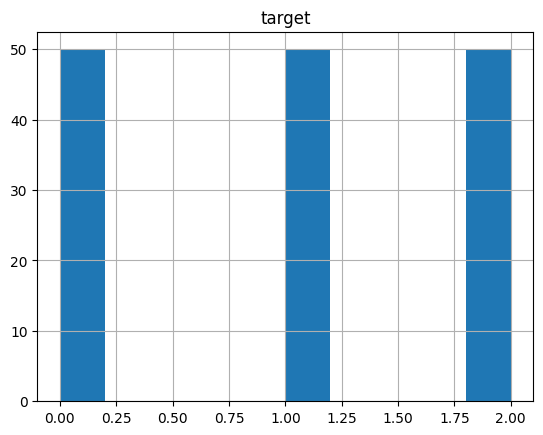

In [4]:
target_df.hist()

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

dtc = DecisionTreeClassifier(random_state=124, min_samples_leaf=6)

kfold = KFold(n_splits=5)

In [7]:
next(kfold.split(feature))[0]

(array([ 30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
         43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
         56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,
         69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,
         82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,
         95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107,
        108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
        121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133,
        134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146,
        147, 148, 149]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]))

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

count = 0
cv_accuracy_list = []

dtc = DecisionTreeClassifier(random_state=124, min_samples_leaf=6)

kfold = KFold(n_splits=5)

for train_index, valid_index in kfold.split(feature):
    count += 1
    X_train, X_valid = feature[train_index], feature[valid_index]
    y_train, y_valid = target[train_index], target[valid_index]

    dtc.fit(X_train, y_train)
    prediction = dtc.predict(X_valid)

    accuracy = np.round(accuracy_score(y_valid, prediction), 4)
    train_size = X_train.shape[0]
    valid_size = X_valid.shape[0]

    print(f'\n#{count} 교차 검증 정확도:{accuracy}, 학습 데이터 크기:{train_size}, 검증 데이터 크기:{valid_size}')
    print(f'#{count} 학습 레이블 데이터 분포:\n', np.unique(y_train, return_counts=True)[1])
    print(f'#{count} 검증 레이블 데이터 분포:\n', np.unique(y_valid, return_counts=True)[1])

    cv_accuracy_list.append(accuracy)
    print("*" * 70)

print(f'▶ 평균 검증 정확도: {np.mean(cv_accuracy_list)}')
    


#1 교차 검증 정확도:1.0, 학습 데이터 크기:120, 검증 데이터 크기:30
#1 학습 레이블 데이터 분포:
 [20 50 50]
#1 검증 레이블 데이터 분포:
 [30]
**********************************************************************

#2 교차 검증 정확도:1.0, 학습 데이터 크기:120, 검증 데이터 크기:30
#2 학습 레이블 데이터 분포:
 [30 40 50]
#2 검증 레이블 데이터 분포:
 [20 10]
**********************************************************************

#3 교차 검증 정확도:0.8333, 학습 데이터 크기:120, 검증 데이터 크기:30
#3 학습 레이블 데이터 분포:
 [50 20 50]
#3 검증 레이블 데이터 분포:
 [30]
**********************************************************************

#4 교차 검증 정확도:0.9333, 학습 데이터 크기:120, 검증 데이터 크기:30
#4 학습 레이블 데이터 분포:
 [50 40 30]
#4 검증 레이블 데이터 분포:
 [10 20]
**********************************************************************

#5 교차 검증 정확도:0.8333, 학습 데이터 크기:120, 검증 데이터 크기:30
#5 학습 레이블 데이터 분포:
 [50 50 20]
#5 검증 레이블 데이터 분포:
 [30]
**********************************************************************
▶ 평균 검증 정확도: 0.91998


### 타겟 데이터의 분포를 동일하게 교차 검증 진행
##### StratifiedKFold.split(features, targets)
- features와 target 모두 전달한다.
- 학습용, 검증용 행 번호를 array로 리턴한다.

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold

dtc = DecisionTreeClassifier(random_state=124, min_samples_leaf=6)

s_kfold = StratifiedKFold(n_splits=5)

for train_index, valid_index in s_kfold.split(feature, target):
    count += 1
    X_train, X_valid = feature[train_index], feature[valid_index]
    y_train, y_valid = target[train_index], target[valid_index]

    dtc.fit(X_train, y_train)
    prediction = dtc.predict(X_valid)

    accuracy = np.round(accuracy_score(y_valid, prediction), 4)
    train_size = X_train.shape[0]
    valid_size = X_valid.shape[0]

    print(f'\n#{count} 교차 검증 정확도:{accuracy}, 학습 데이터 크기:{train_size}, 검증 데이터 크기:{valid_size}')
    print(f'#{count} 학습 레이블 데이터 분포:\n', np.unique(y_train, return_counts=True)[1])
    print(f'#{count} 검증 레이블 데이터 분포:\n', np.unique(y_valid, return_counts=True)[1])

    cv_accuracy_list.append(accuracy)
    print("*" * 70)

print(f'▶ 평균 검증 정확도: {np.mean(cv_accuracy_list)}')



#6 교차 검증 정확도:0.9667, 학습 데이터 크기:120, 검증 데이터 크기:30
#6 학습 레이블 데이터 분포:
 [40 40 40]
#6 검증 레이블 데이터 분포:
 [10 10 10]
**********************************************************************

#7 교차 검증 정확도:0.9667, 학습 데이터 크기:120, 검증 데이터 크기:30
#7 학습 레이블 데이터 분포:
 [40 40 40]
#7 검증 레이블 데이터 분포:
 [10 10 10]
**********************************************************************

#8 교차 검증 정확도:0.9, 학습 데이터 크기:120, 검증 데이터 크기:30
#8 학습 레이블 데이터 분포:
 [40 40 40]
#8 검증 레이블 데이터 분포:
 [10 10 10]
**********************************************************************

#9 교차 검증 정확도:0.8667, 학습 데이터 크기:120, 검증 데이터 크기:30
#9 학습 레이블 데이터 분포:
 [40 40 40]
#9 검증 레이블 데이터 분포:
 [10 10 10]
**********************************************************************

#10 교차 검증 정확도:1.0, 학습 데이터 크기:120, 검증 데이터 크기:30
#10 학습 레이블 데이터 분포:
 [40 40 40]
#10 검증 레이블 데이터 분포:
 [10 10 10]
**********************************************************************
▶ 평균 검증 정확도: 0.93


### 편하게 수행할 수 있는 교차 검증
#### cross_val_score(estimator, x, y, cv, scoring)
- estimator: classifier 종류 모델이면 내부적으로 stratified K-Fold로 진행된다.
- x: featuers
- y: targets
- scoring: 평가 함수, 정확도(accuracy)외에 다른 것은 다른 장에서 배운다.
- cv: 폴드 세트 개수

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score 
from sklearn.datasets import load_iris

iris_data = load_iris()
dtc = DecisionTreeClassifier(random_state=124, min_samples_leaf=6)

feature = iris_data.data
target = iris_data.target

scores = cross_val_score(dtc, feature, target, cv=5, scoring='accuracy')
print(f'교차 검증별 정확도 {scores}')
print(f'평균 정확도', np.mean(scores))

교차 검증별 정확도 [0.96666667 0.96666667 0.9        0.86666667 1.        ]
평균 정확도 0.9400000000000001


#### RandomizedSearchCV(estimator, param_distributions, n_iter, cv, refit, return_train_score)
- 제시된 하이퍼 파라미터 수치 중 무작위로 뽑아서 실행한다.
- estimator: 학습할 모델 객체 작성
- param_distributions: dict 형태로 전달해야 한다.  
리스트([2, 3, 4])를 전달하여 그 안에서 고르게 하거나, scipy.stats의 분포 함수(예: randint)를 전달하여 특정 범위 내에서 무작위 숫자를 생성하게 할 수 있다.
- n_iter: 전체 파라미터 조합 중 실제로 몇 번을 무작위로 뽑아서 실행할지 횟수를 지정한다(값이 클수록 정확도는 높아지지만 시간이 오래 걸림).
- cv: 폴드 세트 개수.
- refit: 최적의 하이퍼 파라미터를 찾은 뒤, 해당 파라미터로 estimator를 다시 훈련시킬지 여부입니다. True로 설정하면 best_estimator_ 속성에 최종 학습된 모델이 저장된다. 디폴트는 True.
- return_train_score: 교차 검증 점수를 가져올 지에 대해 True 또는 False를 전달한다.

In [14]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import randint

iris = load_iris()

X_train, X_test, y_train, y_test = \
train_test_split(iris_data.data, 
                 iris_data.target, 
                 test_size=0.2, 
                 stratify=iris_data.target, 
                 random_state=124)

dtc = DecisionTreeClassifier()

parameters = {
    'max_depth': randint(2, 10),
    'min_samples_split': randint(2, 20)
}

random_cv = RandomizedSearchCV(
    dtc,
    param_distributions=parameters,
    n_iter=4,
    cv=5,
    refit=True,
    return_train_score=True,
    random_state=124
)

random_cv.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_distributions,"{'max_depth': <scipy.stats....00201DFE0CA00>, 'min_samples_split': <scipy.stats....00201E0781F60>}"
,n_iter,4
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,124
,error_score,nan


In [18]:
random_cv_scores = pd.DataFrame(random_cv.cv_results_)
random_cv_scores[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score')

,params,mean_test_score,rank_test_score
2,"{'max_depth': 3, 'min_samples_split': 2}",0.941667,1
0,"{'max_depth': 8, 'min_samples_split': 19}",0.933333,2
1,"{'max_depth': 9, 'min_samples_split': 4}",0.933333,2
3,"{'max_depth': 6, 'min_samples_split': 16}",0.933333,2


In [21]:
print(random_cv.best_params_)
print(random_cv.best_score_)
print(random_cv.best_estimator_)

{'max_depth': 3, 'min_samples_split': 2}
0.9416666666666667
DecisionTreeClassifier(max_depth=3)


#### GridSearchCV(estimator, param_grid, cv, refit, return_train_score)
- 제시된 하이퍼 파라미터 수치를 모든 경우의 수로 실행한다.
- estimator: 학습할 모델 객체 작성
- param_grid: dict형태로 전달해야 함.
- cv: 폴드 세트 개수
- refit: 최적의 하이퍼 파라미터를 찾은 뒤, 해당 파라미터로 estimator를 다시 훈련시킬지 여부입니다. True로 설정하면 best_estimator_ 속성에 최종 학습된 모델이 저장된다. 디폴트는 True.
- return_train_score: 교차 검증 점수를 가져올 지에 대해 True 또는 False를 전달한다.

In [23]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import randint

iris = load_iris()

X_train, X_test, y_train, y_test = \
train_test_split(iris_data.data, 
                 iris_data.target, 
                 test_size=0.2, 
                 stratify=iris_data.target, 
                 random_state=124)

dtc = DecisionTreeClassifier(random_state=124)

parameters = {
    'max_depth': [3, 4, 5, 6, 7, 8, 9],
    'min_samples_split': list(range(2, 20))
}

grid_cv = GridSearchCV(
    dtc,
    param_grid=parameters,
    cv=3,
    refit=True,
    return_train_score=True,
)

grid_cv.fit(X_train, y_train)

,estimator,DecisionTreeC...dom_state=124)
,param_grid,"{'max_depth': [3, 4, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [28]:
grid_cv_scores = pd.DataFrame(grid_cv.cv_results_)
grid_cv_scores[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score').head(20)

,params,mean_test_score,rank_test_score
0,"{'max_depth': 3, 'min_samples_split': 2}",0.941667,1
1,"{'max_depth': 3, 'min_samples_split': 3}",0.941667,1
2,"{'max_depth': 3, 'min_samples_split': 4}",0.941667,1
3,"{'max_depth': 3, 'min_samples_split': 5}",0.941667,1
4,"{'max_depth': 3, 'min_samples_split': 6}",0.941667,1
5,"{'max_depth': 3, 'min_samples_split': 7}",0.941667,1
6,"{'max_depth': 3, 'min_samples_split': 8}",0.941667,1
7,"{'max_depth': 3, 'min_samples_split': 9}",0.941667,1
8,"{'max_depth': 3, 'min_samples_split': 10}",0.941667,1
9,"{'max_depth': 3, 'min_samples_split': 11}",0.941667,1


In [29]:
print(grid_cv.best_params_)
print(grid_cv.best_score_)
print(grid_cv.best_estimator_)

{'max_depth': 3, 'min_samples_split': 2}
0.9416666666666668
DecisionTreeClassifier(max_depth=3, random_state=124)
